# Desenvolver, avaliar e pontuar um modelo de previsão para vendas

## Introdução

Este tutorial apresenta um exemplo de ponta a ponta de um fluxo de pipeline de Ciência de Dados. 
O cenário cria um modelo de previsão que usa dados históricos de vendas para prever vendas de categoria de produto.

A previsão é um ativo crucial nas vendas, ela combina dados históricos e métodos preditivos para fornecer insights sobre tendências futuras. A previsão pode analisar vendas passadas para identificar padrões. Ele também pode aprender com o comportamento do consumidor para otimizar estratégias de inventário, produção e marketing. Essa abordagem proativa aprimora a adaptabilidade, a capacidade de resposta e o desempenho geral dos negócios em um marketplace dinâmico.

Este tutorial aborda estas Fases:

1. Importação das Bibliotecas / configuração ambiente
2. Extração dos Dados
3. Análise Exploratória de Dados (EDA)


Treinar um modelo de machine learning com um pacote de software livre
Acompanhar experimentos com o MLflow e o recurso de registro automático do Fabric
Salvar o modelo final de machine learning e fazer previsões
Mostrar o desempenho do modelo com visualizações do Power BI


## Pré-requisitos
- [...](https://) para este notebook.


## 1. Importação das Bibliotecas / configuração ambiente

In [8]:
# Importando bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

import warnings
#import itertools

warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
import matplotlib
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

import os
import sys
from pathlib import Path

# Configurações para melhor visualização
pd.set_option('display.float_format', lambda x: '%.4f' % x)

from IPython.display import display, Markdown


In [67]:
%reload_ext watermark
%watermark -a "Hilario Gouveia" -v --iversions

Author: Hilario Gouveia

Python implementation: CPython
Python version       : 3.14.3
IPython version      : 9.15.0

IPython    : 9.15.0
matplotlib : 3.11.0
numpy      : 2.5.1
pandas     : 3.0.3
seaborn    : 0.13.2
sklearn    : 1.9.0
statsmodels: 0.14.6
xgboost    : 3.3.0



## 2. Extração dos Dados

In [38]:
# Garante que o notebook perceba a pasta `src/` e os caminhos relativos (ex.: "data/raw/...") 
# independente de onde o Jupyter foi iniciado, seja na raiz do projeto, seja dentro de notebooks/.

_root = Path.cwd()
while not (_root / "src").is_dir() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

os.makedirs("data/final", exist_ok=True)

df = pd.read_csv("data/final/vendas_final.csv")

In [18]:
# Exibir dados do dataset final do DataView
display(Markdown("### Exibir dados"))
display(df, summary=True)

### Exibir dados

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,trimestre,ano,faixa_receita_item
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0000,240.0000,1,Q 1,2024,Baixo Valor
1,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0000,840.0000,6,Q 2,2024,Médio Valor
2,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0000,10800.0000,11,Q 4,2024,Alto Valor
3,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0000,14000.0000,5,Q 2,2024,Alto Valor
4,8,2024-06-30,Cliente_020,Smartphone,Celulares,Sul,6,2200.0000,13200.0000,6,Q 2,2024,Alto Valor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,146,2024-08-09,Cliente_019,Notebook,Computadores,Norte,2,3500.0000,7000.0000,8,Q 3,2024,Alto Valor
130,147,2024-12-09,Cliente_028,Teclado,Periféricos,Sudeste,6,250.0000,1500.0000,12,Q 4,2024,Médio Valor
131,148,2024-06-08,Cliente_008,Tablet,Celulares,Sudeste,10,1800.0000,18000.0000,6,Q 2,2024,Alto Valor
132,149,2024-07-07,Cliente_018,Tablet,Celulares,Norte,9,1800.0000,16200.0000,7,Q 3,2024,Alto Valor


## 3. Análise Exploratória dos Dados (EDA)

In [39]:
# Informações gerais do DataFrame
display(Markdown("### Informações Gerais do DataFrame"))
df.info()

### Informações Gerais do DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_venda            134 non-null    int64  
 1   data_venda          134 non-null    str    
 2   cliente             134 non-null    str    
 3   produto             134 non-null    str    
 4   categoria           134 non-null    str    
 5   regiao              134 non-null    str    
 6   quantidade          134 non-null    int64  
 7   preco_unitario      134 non-null    float64
 8   receita_total       134 non-null    float64
 9   mes                 134 non-null    int64  
 10  trimestre           134 non-null    str    
 11  ano                 134 non-null    int64  
 12  faixa_receita_item  134 non-null    str    
dtypes: float64(2), int64(4), str(7)
memory usage: 13.7 KB


In [50]:
# Resumo estatístico
display(Markdown("### Resumo Estatístico das Variáveis Numéricas"))
display(df.describe().T)

### Resumo Estatístico das Variáveis Numéricas

,count,mean,std,min,25%,50%,75%,max
id_venda,134.0000,77.4478,42.9783,1.0000,41.2500,79.0000,114.5000,150.0000
quantidade,134.0000,5.2761,2.8028,1.0000,3.0000,5.0000,8.0000,10.0000
preco_unitario,134.0000,1446.9403,1135.0170,120.0000,250.0000,1200.0000,2200.0000,3500.0000
receita_total,134.0000,6928.7313,6473.8639,120.0000,1200.0000,5100.0000,10800.0000,24500.0000
mes,134.0000,6.3433,3.3742,1.0000,4.0000,6.0000,9.0000,12.0000
ano,134.0000,2024.0000,0.0000,2024.0000,2024.0000,2024.0000,2024.0000,2024.0000


In [23]:
# Resumo estatístico
display(Markdown("### Resumo Estatístico das Variáveis Categóricas"))
display(df.describe(include='object').T)

### Resumo Estatístico das Variáveis Categóricas

,count,unique,top,freq
data_venda,134,108,2024-11-22,3
cliente,134,29,Cliente_020,7
produto,134,6,Mouse,27
categoria,134,3,Celulares,47
regiao,134,5,Norte,37
trimestre,134,4,Q 2,36
faixa_receita_item,134,3,Alto Valor,67


In [25]:
# Intervalo de dados

display(Markdown("### Exibir intervalo de datas"))
print(df['data_venda'].min(), df['data_venda'].max())

### Exibir intervalo de datas

2024-01-08 2024-12-27


In [47]:
# Data preparation

# Impacto da data da venda nas vendas
df_temporal = df.groupby('data_venda')['receita_total'].sum().reset_index()
df_temporal['data_venda'] = pd.to_datetime(df['data_venda'], errors='coerce')
df_temporal = df_temporal.set_index('data_venda')

# Garantir que o índice seja um DatetimeIndex para resample()
df_temporal.index = pd.DatetimeIndex(df_temporal.index)

y = df_temporal['receita_total'].resample('MS').mean()
y = y.reset_index()
y['data_venda'] = pd.to_datetime(y['data_venda'], errors='coerce')
y['data_venda'] = [i + pd.DateOffset(months=12) for i in y['data_venda']]
y = y.set_index(['data_venda'])
maximum_date = y.index.max()

Demonstra o impacto da data_venda sobre receita_total e têndencia (média móvel)

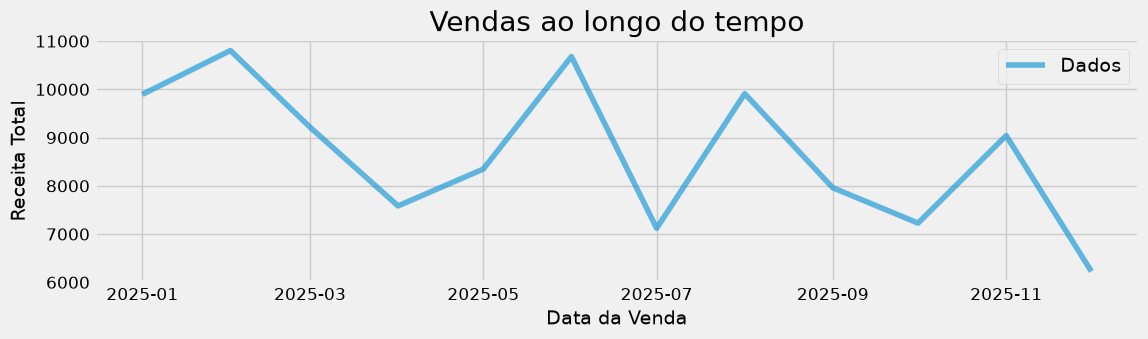

In [49]:
# Plotar dados e tendência (média móvel)
y_rolling = y.rolling(window=3).mean()
plt.figure(figsize=(12, 3))
plt.plot(y.index, y.values, label='Dados', alpha=0.6)
#plt.plot(y_rolling.index, y_rolling.values, label='Tendência (média móvel)', linewidth=2)
plt.title('Vendas ao longo do tempo')
plt.xlabel('Data da Venda')
plt.ylabel('Receita Total')
plt.legend()
plt.show()

### Realizar análise estatística
Uma série temporal acompanha esses elementos de dados em intervalos definidos, para determinar a variação desses elementos no padrão da série temporal:

- **Nível:** O componente fundamental que representa o valor médio para um período de tempo específico.

- **Tendência:** Descreve se a série temporal diminui, permanece constante ou aumenta ao longo do tempo.

- **Sazonalidade:** Descreve o sinal periódico na série temporal e busca ocorrências cíclicas que impactam os padrões crescentes ou decrescentes das séries temporais.

- **Ruído/Residual:** Refere-se às flutuações aleatórias e variabilidade nos dados das séries temporais que o modelo não consegue explicar.

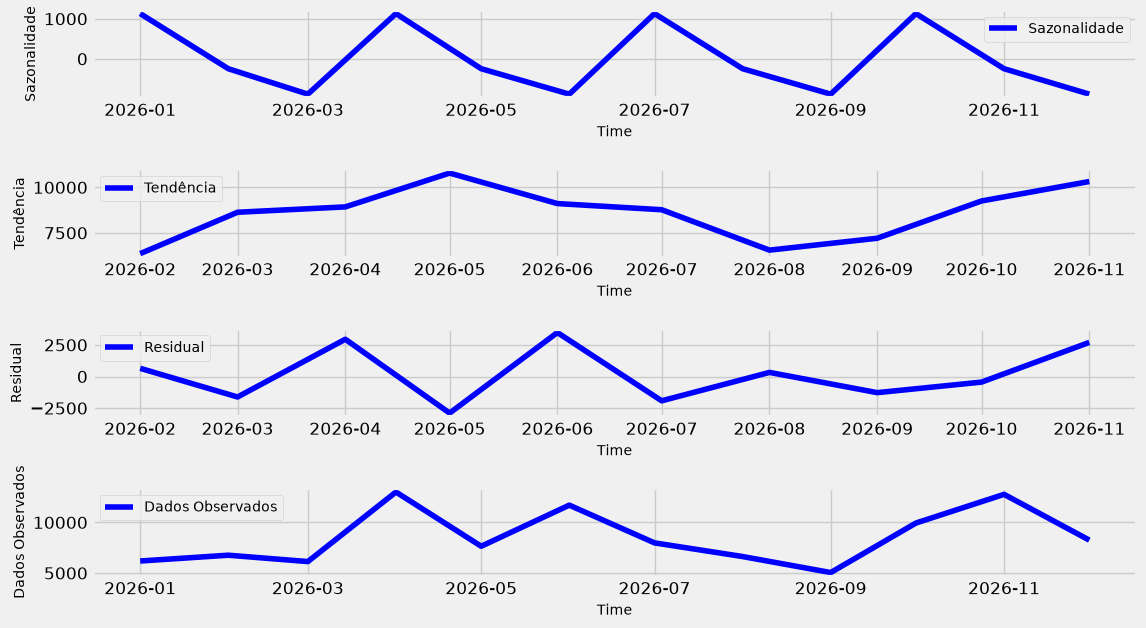

In [34]:
# Decompose the time series into its components by using statsmodels
result = sm.tsa.seasonal_decompose(y, model='additive', period=3)

# Labels and corresponding data for plotting
components = [('Sazonalidade', result.seasonal),
              ('Tendência', result.trend),
              ('Residual', result.resid),
              ('Dados Observados', y)]

# Create subplots in a grid
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 7))
plt.subplots_adjust(hspace=0.8)  # Adjust vertical space
axes = axes.ravel()

# Plot the components
for ax, (label, data) in zip(axes, components):
    ax.plot(data, label=label, color='blue' if label != 'Observed Data' else 'purple')
    ax.set_xlabel('Time')
    ax.set_ylabel(label)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=10)

plt.show()

Os gráficos descrevem a sazonalidade, tendências e ruído nos dados de previsão. Você pode capturar os padrões subjacentes e desenvolver modelos que façam previsões precisas e resilientes contra flutuações aleatórias.

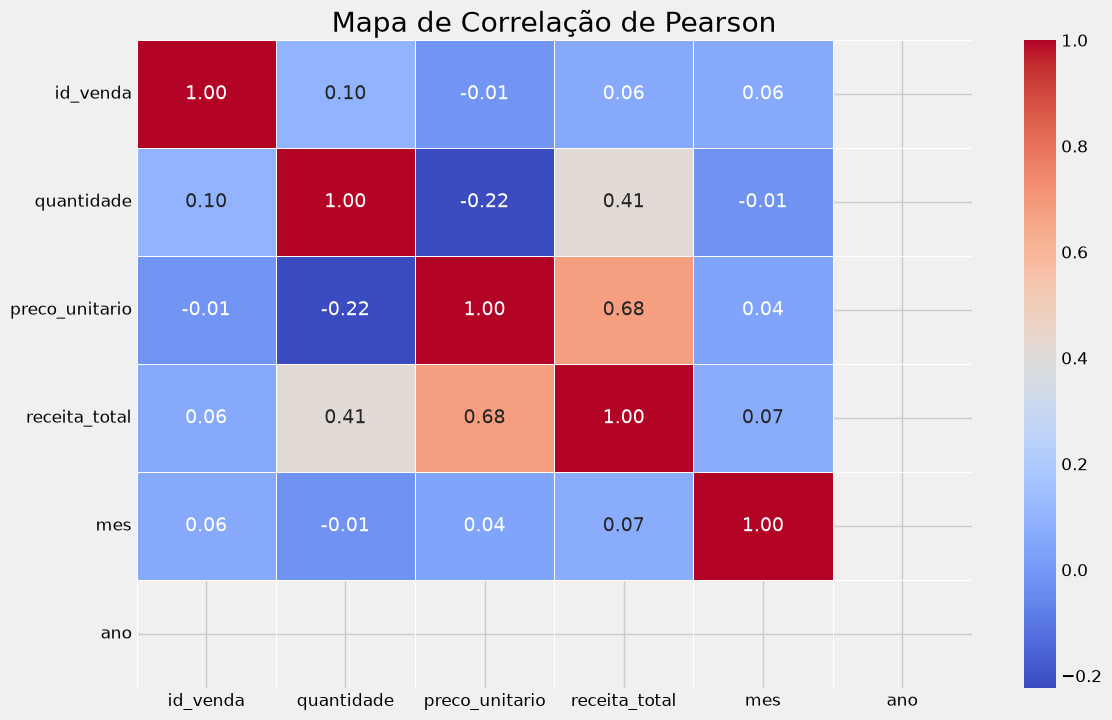

Variáveis com alta multicolinearidade (sugestão de remoção): []


In [40]:
# Identificação e Visualização de Multicolinearidade

# 1. Calcular a matriz de correlação apenas com variáveis numéricas
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. Plotar o Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlação de Pearson")
plt.show()

# 3. Identificar pares com correlação quase perfeita (> 0.90)
# Criamos uma máscara para pegar apenas o triângulo superior da matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Encontrar colunas com correlação alta
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.90)]

print(f"Variáveis com alta multicolinearidade (sugestão de remoção): {to_drop}")

In [52]:
# Data Preparation for Machine Learning
# Seleção de Features 
#  Removendo variáveis preditivas ('receita_total', 'faixa_receita_item') que causaria Leakage.
#  Removendo variáveis ('id_venda', 'cliente') que não tem importância para o modelo.

features = df.drop(columns=['receita_total', 'faixa_receita_item', 'id_venda', 'cliente'])

display(Markdown("### Exibir Features para Machine Learning"))
display(features, summary=True)


### Exibir Features para Machine Learning

,data_venda,produto,categoria,regiao,quantidade,preco_unitario,mes,trimestre,ano
0,2024-01-13,Mouse,Periféricos,Norte,2,120.0000,1,Q 1,2024
1,2024-06-23,Mouse,Periféricos,Sudeste,7,120.0000,6,Q 2,2024
2,2024-11-05,Tablet,Celulares,Centro-Oeste,6,1800.0000,11,Q 4,2024
3,2024-05-28,Notebook,Computadores,Nordeste,4,3500.0000,5,Q 2,2024
4,2024-06-30,Smartphone,Celulares,Sul,6,2200.0000,6,Q 2,2024
...,...,...,...,...,...,...,...,...,...
129,2024-08-09,Notebook,Computadores,Norte,2,3500.0000,8,Q 3,2024
130,2024-12-09,Teclado,Periféricos,Sudeste,6,250.0000,12,Q 4,2024
131,2024-06-08,Tablet,Celulares,Sudeste,10,1800.0000,6,Q 2,2024
132,2024-07-07,Tablet,Celulares,Norte,9,1800.0000,7,Q 3,2024


In [55]:
# Engenharia de Atributos

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Definir variável dependente (o que queremos prever)
target_reg = df['receita_total']
target_clf = df['faixa_receita_item']

# 2. Definição de colunas categóricas e numéricas
cat_cols = features.select_dtypes(include=['object', 'category']).columns
num_cols = features.select_dtypes(include=['int64', 'float64']).columns

# 3. Construção do Pipeline de Pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# Divisão treino/teste (essencial para evitar overfitting)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(features, target_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(features, target_clf, test_size=0.2, random_state=42)

print("Pipeline de pré-processamento pronto e dados divididos.")

Pipeline de pré-processamento pronto e dados divididos.


In [68]:
display(X_train)

,data_venda,produto,categoria,regiao,quantidade,preco_unitario,mes,trimestre,ano
11,2024-05-16,Mouse,Periféricos,Nordeste,9,120.0000,5,Q 2,2024
51,2024-08-06,Teclado,Periféricos,Centro-Oeste,9,250.0000,8,Q 3,2024
93,2024-05-04,Monitor,Computadores,Sul,8,1200.0000,5,Q 2,2024
122,2024-10-28,Tablet,Celulares,Sudeste,4,1800.0000,10,Q 4,2024
125,2024-11-15,Smartphone,Celulares,Nordeste,5,2200.0000,11,Q 4,2024
...,...,...,...,...,...,...,...,...,...
71,2024-10-01,Tablet,Celulares,Norte,2,1800.0000,10,Q 4,2024
106,2024-01-12,Tablet,Celulares,Sudeste,5,1800.0000,1,Q 1,2024
14,2024-09-05,Notebook,Computadores,Centro-Oeste,2,3500.0000,9,Q 3,2024
92,2024-11-27,Monitor,Computadores,Centro-Oeste,2,1200.0000,11,Q 4,2024


In [65]:
# 1. Implementação dos Modelos de Regressão

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from importlib import reload
import src.ml_utils as ml_utils
reload(ml_utils)
from src.ml_utils import avaliar_regressao # Importando a função que criamos anteriormente

# Definindo o seletor: manterá apenas as 5 melhores variáveis
selector = RFE(estimator=RandomForestRegressor(), n_features_to_select=5)

# Definindo os modelos
modelos_reg = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42)
}

resultados_reg = []

# Loop de Treino e Avaliação
for nome, modelo in modelos_reg.items():
    # Criando um pipeline completo para cada modelo
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('feature_selection', selector), # Adiciona o seletor aqui
                           ('regressor', modelo)])
    
    # Treino
    pipe.fit(X_train, y_train_reg)
    
    # Predição
    y_pred = pipe.predict(X_test)
    
    # Avaliação
    metricas = avaliar_regressao(y_test_reg, y_pred, nome)
    metricas['Modelo'] = nome
    resultados_reg.append(metricas)

# Transformando resultados em DataFrame para comparação
df_resultados_reg = pd.DataFrame(resultados_reg)

# 3. Tabela de Comparação de Métricas
print("Resumo Comparativo de Modelos:")
display(df_resultados_reg)

--- Linear Regression ---
MAE: 1920.52 | RMSE: 2471.53 | R²: 0.82
--- Random Forest ---
MAE: 139.94 | RMSE: 270.93 | R²: 1.00
--- XGBoost ---
MAE: 5.45 | RMSE: 28.16 | R²: 1.00
Resumo Comparativo de Modelos:


,MAE,RMSE,R2,Modelo
0,1920.5245,2471.5304,0.8157,Linear Regression
1,139.9407,270.9337,0.9978,Random Forest
2,5.4492,28.1563,1.0000,XGBoost


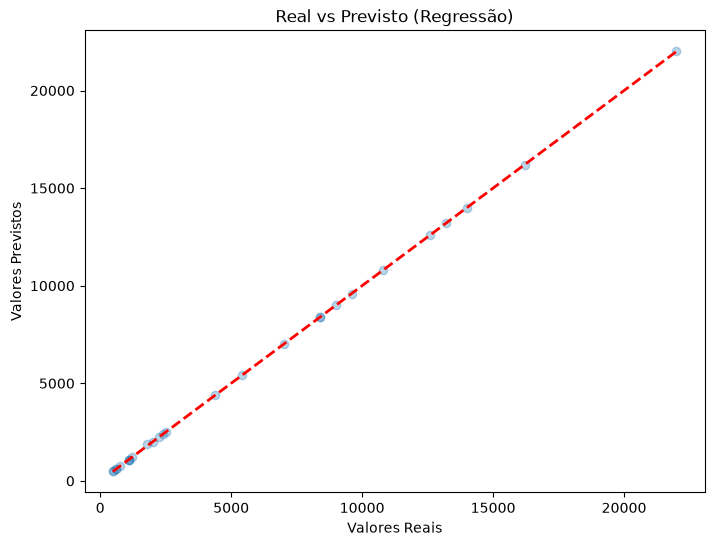

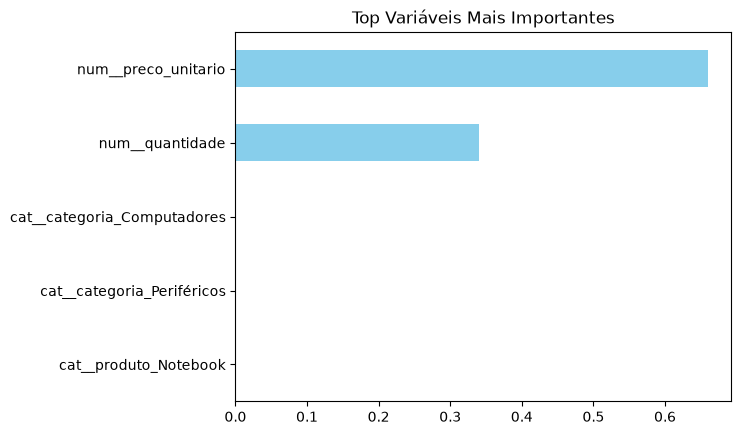

Resumo Comparativo de Modelos:


,MAE,RMSE,R2,Modelo
0,1932.3198,2477.4298,0.8148,Linear Regression
1,139.9407,270.9337,0.9978,Random Forest
2,2.8566,14.7587,1.0000,XGBoost


In [32]:
from src.ml_utils import plot_feature_importance

# 1. Gráfico Real x Previsto (usando o melhor modelo, ex: XGBoost)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, alpha=0.3) # y_pred aqui deve ser do melhor modelo
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")
plt.title("Real vs Previsto (Regressão)")
plt.show()

# 2. Importância das Variáveis (usando a função do ml_utils)
# Escolha o modelo que teve o melhor R²
modelo_campeao = pipe.named_steps['regressor']
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
selector_mask = pipe.named_steps['feature_selection'].get_support()
selected_feature_names = feature_names[selector_mask]
plot_feature_importance(modelo_campeao, selected_feature_names)

# 3. Tabela de Comparação de Métricas
print("Resumo Comparativo de Modelos:")
display(df_resultados_reg)

### Interpretação do Gráfico Real vs Previsto
O gráfico Real vs Previsto mostra o desempenho do melhor modelo de regressão (XGBoost) ao comparar os valores observados com os valores previstos.

- A maioria dos pontos está agrupada próxima à linha diagonal, indicando que o modelo faz previsões muito próximas dos valores reais.
- Pontos acima da linha representam previsões que ficaram acima do valor real; pontos abaixo representam previsões abaixo do valor real.
- A dispersão limitada em torno da diagonal sugere baixa variabilidade de erro e um ajuste geral consistente dos dados de teste.

Esse gráfico reforça que o modelo foi capaz de capturar bem o padrão das vendas, com poucas previsões fora da faixa esperada.

In [59]:
# 1. Implementação dos Modelos de Classificação
#from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from importlib import reload
import src.ml_utils as ml_utils
reload(ml_utils)
from src.ml_utils import avaliar_classificacao

# Definindo os modelos
modelos_clf = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

resultados_clf = []

# Loop de Treino e Avaliação
for nome, modelo in modelos_clf.items():
    # Pipeline para Classificação
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', modelo)])
    
    # Treino
    pipe.fit(X_train, y_train_clf)
    
    # Predição
    y_pred = pipe.predict(X_test)
    
    # Avaliação
    metricas = avaliar_classificacao(y_test_clf, y_pred, nome)
    metricas['Modelo'] = nome
    resultados_clf.append(metricas)

# Tabela comparativa
df_resultados_clf = pd.DataFrame(resultados_clf)

--- Logistic Regression ---
Acc: 0.93 | Prec: 0.86 | Recall: 0.93 | F1: 0.89
--- Decision Tree ---
Acc: 1.00 | Prec: 1.00 | Recall: 1.00 | F1: 1.00
--- Random Forest ---
Acc: 0.93 | Prec: 0.86 | Recall: 0.93 | F1: 0.89


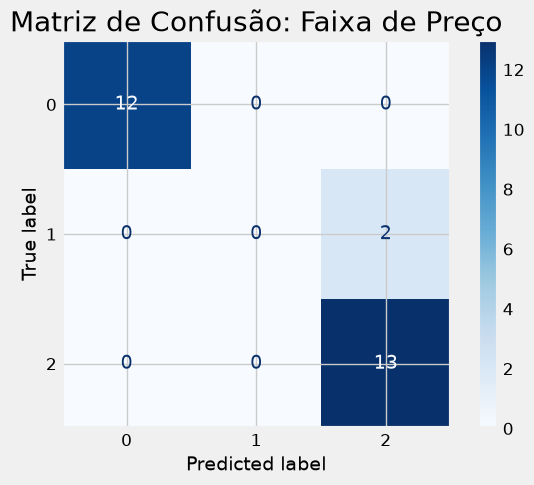

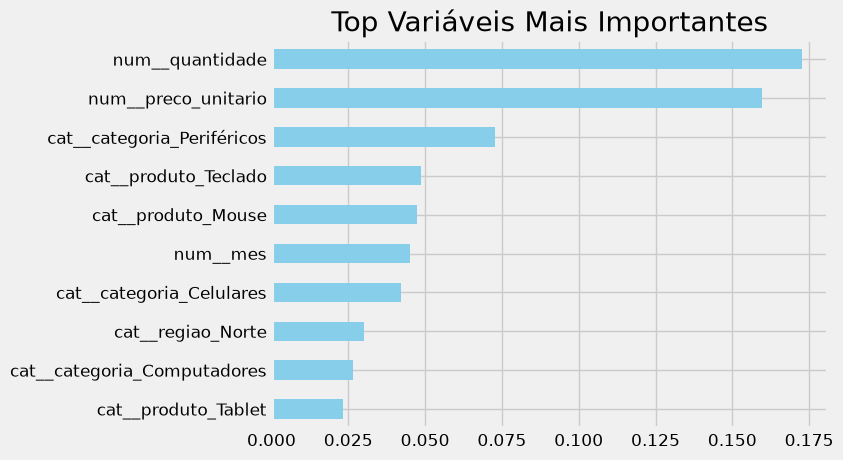

In [63]:
# 2. Análise de Desempenho e Visualização
# Visualização da Matriz de Confusão e Importância das Variáveis

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from importlib import reload
import src.ml_utils as ml_utils
reload(ml_utils)
from src.ml_utils import plot_feature_importance

# Visualização da Matriz de Confusão do melhor modelo
modelo_campeao_clf = pipe.named_steps['classifier']
y_pred_final = pipe.predict(X_test)

cm = confusion_matrix(y_test_clf, y_pred_final)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Matriz de Confusão: Faixa de Preço")
plt.show()

# Importância das Variáveis para o melhor classificador
feature_names_clf = pipe.named_steps['preprocessor'].get_feature_names_out()
plot_feature_importance(modelo_campeao_clf, feature_names_clf)

In [66]:
# Etapa Final: Tabela Comparativa Geral
# Unindo os resultados em um único DataFrame para o portfólio
# Vamos criar uma coluna para diferenciar o tipo de problema

df_resultados_reg['Tipo'] = 'Regressão'
df_resultados_clf['Tipo'] = 'Classificação'

# Consolidando (ajustando colunas para que fiquem alinhadas)
df_final = pd.concat([df_resultados_reg, df_resultados_clf], ignore_index=True)

# Exibindo a tabela final que você usará no README ou na conclusão do Notebook
print("Tabela Comparativa Geral de Modelos:")
display(df_final[['Tipo', 'Modelo', 'MAE', 'R2', 'Accuracy', 'F1']])

Tabela Comparativa Geral de Modelos:


,Tipo,Modelo,MAE,R2,Accuracy,F1
0,Regressão,Linear Regression,1920.5245,0.8157,NaN,NaN
1,Regressão,Random Forest,139.9407,0.9978,NaN,NaN
2,Regressão,XGBoost,5.4492,1.0000,NaN,NaN
3,Classificação,Logistic Regression,NaN,NaN,0.9259,0.8915
4,Classificação,Decision Tree,NaN,NaN,1.0000,1.0000
5,Classificação,Random Forest,NaN,NaN,0.9259,0.8915
